# Master Analysis Notebook: Welfare Institutions and the Politics of Economic Disruption

*A pedagogical reconstruction of the seminar paper's empirical spine, built to be learned from and to catch mistakes.*

This notebook rebuilds, from the raw master file, every analysis that survived into the final paper. It is written in the Mostly Harmless tradition: intuition before terminology, concrete before abstract, numbers before symbols. Before each step there is a plain statement of *what comparison is doing the work and what question that comparison answers*, then the code, then the number, then an honest note on what the number licenses and what it does not.

**How to use it.** Run top to bottom (Restart & Run All). Every section ends with a self-test "check" cell (question first, answer folded below). Every section also ends with a running `Anomalies & things to check` cell. The final section consolidates everything that looked wrong or did not reconcile.

**Single source of truth.** `outputs/tables/rs_results.csv` is canonical for Models 1 to 5. Every headline number in this notebook is cross-checked against it or against the manuscript, and disagreements are reported, not smoothed over.

**What this notebook is not.** It is not the pipeline. It does not modify `analysis/final_analysis_pipeline.py`, `scripts/random_slopes_models.py`, or `analysis/_diagnose_cwed_correlation.py`. It reads the same data and reproduces.

**No celebratory framing.** A number is stated with what it is and what it allows you to claim. The reader decides whether it is impressive.

---
## Section 0. The single source of truth

Before any modelling, the discipline. A paper's credibility is not in its prose; it is in whether every number in the prose traces to a script that someone else could run. The canonical random-slopes results live in `outputs/tables/rs_results.csv`. If a number in the paper cannot be found there (or in a named companion script), the number is not yet real.

This section does one thing: load that CSV and confirm the paper's five headline coefficients are exactly what it says. This is the meta-lesson the rest of the notebook depends on. It is Section 0 because if you cannot reproduce the table of record, nothing downstream is trustworthy.

The five anchors we will hold the whole notebook to:

| Model | What it estimates | Anchor |
|---|---|---|
| M1 | RTI baseline effect on anti-immigration | β=0.168, N=133,016 |
| M2 | RTI × Liberal regime interaction | β=0.127, p=0.003 |
| M3 | RTI × CWED generosity (cross-level) | β=−0.059, SE=0.024, p=0.015, N=81,885 |
| M5 | RTI × Liberal on *redistribution* (the asymmetric null) | RTI β=0.041; RTI×Liberal β=0.013, SE=0.019, p=0.488 |
| Country-level | BLUP correlation of slopes with CWED | r=−0.848 (OLS comparator r=−0.625) |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
from scipy import stats as st
import itertools

# Run from the repo root so every relative path resolves the way the
# canonical scripts expect.
REPO = r'C:\Users\PKF715\Documents\claude_repos\Research_Master'
os.chdir(REPO)
print('Working directory:', os.getcwd())

pd.set_option('display.float_format', lambda v: f'{v:,.4f}')
pd.set_option('display.max_columns', 40)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

Working directory: C:\Users\PKF715\Documents\claude_repos\Research_Master


**Why this cell exists.** Load the table of record and read the paper's headline numbers straight off it. No estimation yet. If these do not match the paper, every later reconstruction is suspect, and we stop.

`rs_results.csv` is wide: one row per model, with the RTI coefficient in `rti_coef` and each interaction stored as `int_<name>` columns. We pull the five anchors and print them next to the paper's claimed values.

In [2]:
rs = pd.read_csv('outputs/tables/rs_results.csv')
print('rs_results.csv rows:', rs.shape[0], '| columns:', rs.shape[1])
print('Models present:', list(rs['model']))
print()

def row(model):
    return rs.loc[rs['model'] == model].iloc[0]

m1 = row('M1_baseline_rs')
m2 = row('M2_regime_rs')
m3 = row('M3_cwed_rs')
m5 = row('M5_redistribution_rs')

anchors = pd.DataFrame([
    ['M1  RTI baseline (beta)',        m1['rti_coef'],  0.168,   'paper: 0.168'],
    ['M1  N',                          m1['n_obs'],     133016,  'paper: 133,016'],
    ['M2  RTI x Liberal (beta)',       m2['int_task_z:welfare_regime[T.Liberal]'], 0.127, 'paper: 0.127'],
    ['M2  RTI x Liberal (p)',          m2['int_task_z:welfare_regime[T.Liberal]_p'], 0.003, 'paper: 0.003'],
    ['M2  RTI x Eastern (beta)',       m2['int_task_z:welfare_regime[T.Eastern]'], -0.132, 'paper: -0.132'],
    ['M3  RTI x CWED (beta)',          m3['int_task_z:cwed_generosity_z'], -0.059, 'paper: -0.059'],
    ['M3  RTI x CWED (SE)',            m3['int_task_z:cwed_generosity_z_se'], 0.024, 'paper: 0.024'],
    ['M3  RTI x CWED (p)',             m3['int_task_z:cwed_generosity_z_p'], 0.015, 'paper: 0.015'],
    ['M3  N',                          m3['n_obs'],     81885,   'paper: 81,885'],
    ['M5  RTI (beta)',                 m5['rti_coef'],  0.041,   'paper: 0.041'],
    ['M5  RTI x Liberal (beta)',       m5['int_task_z:welfare_regime[T.Liberal]'], 0.013, 'paper: 0.013'],
    ['M5  RTI x Liberal (SE)',         m5['int_task_z:welfare_regime[T.Liberal]_se'], 0.019, 'paper: 0.019'],
    ['M5  RTI x Liberal (p)',          m5['int_task_z:welfare_regime[T.Liberal]_p'], 0.488, 'paper: 0.488'],
], columns=['quantity', 'rs_results.csv', 'paper_claim', 'note'])

anchors['matches'] = (
    (anchors['rs_results.csv'] - anchors['paper_claim']).abs()
    <= anchors['paper_claim'].abs() * 0.02 + 0.0011
)
print(anchors.to_string(index=False))
print()
print('All five anchors reconcile with the paper:' , bool(anchors['matches'].all()))

rs_results.csv rows: 5 | columns: 42
Models present: ['M1_baseline_rs', 'M2_regime_rs', 'M3_cwed_rs', 'M4_education_rs', 'M5_redistribution_rs']

                quantity  rs_results.csv  paper_claim           note  matches
 M1  RTI baseline (beta)          0.1681       0.1680   paper: 0.168     True
                   M1  N    133,016.0000 133,016.0000 paper: 133,016     True
M2  RTI x Liberal (beta)          0.1271       0.1270   paper: 0.127     True
   M2  RTI x Liberal (p)          0.0033       0.0030   paper: 0.003     True
M2  RTI x Eastern (beta)         -0.1325      -0.1320  paper: -0.132     True
   M3  RTI x CWED (beta)         -0.0592      -0.0590  paper: -0.059     True
     M3  RTI x CWED (SE)          0.0244       0.0240   paper: 0.024     True
      M3  RTI x CWED (p)          0.0151       0.0150   paper: 0.015     True
                   M3  N     81,885.0000  81,885.0000  paper: 81,885     True
          M5  RTI (beta)          0.0410       0.0410   paper: 0.041     T

> **Check (Section 0).** The paper reports M3's interaction as β=−0.059 with a larger standard error than the simpler models. Where does that number live, and what would it mean if `rs_results.csv` showed −0.030 instead?
>
> <details><summary>Answer</summary>
> It lives in the `M3_cwed_rs` row, column `int_task_z:cwed_generosity_z`, in `outputs/tables/rs_results.csv`. If the CSV showed −0.030 we would *stop*: either the paper misreports its own table of record, or the canonical script changed and the manuscript was not updated. Reconciliation failure is a halt condition, not a rounding footnote.
> </details>

### Anomalies & things to check (Section 0)

Nothing yet; this is the baseline. If any anchor above prints `matches=False`, that is the first thing to investigate before reading on.

---
## Section 1. The raw materials

The paper combines three kinds of data, and the joins between them are where silent errors enter.

1. **European Social Survey (ESS), waves 6 to 9.** Repeated cross-sections of individuals: their attitudes, their occupation (ISCO-08), demographics. This is the spine.
2. **ISCO-08 task scores.** A separate table mapping 3-digit occupation codes to a Routine Task Intensity (RTI) score. RTI is the column literally named `task` (not `rtask`, not `nrtask`; this naming has tripped people before). ESS carries 4-digit ISCO; the task table is 3-digit, so ISCO must be truncated `isco08 // 10` *before* the merge or every row misses.
3. **CWED (Comparative Welfare Entitlements Dataset).** Country-level welfare generosity. It ends in 2011; ESS fieldwork here is 2012 to 2018. The paper's choice: collapse CWED to a single time-invariant country mean over 2005 to 2011 and merge on country. This is a deliberate measurement decision with a coverage cost we will quantify, not hide.

For this notebook we read one consolidated file, `analysis/sorting_mechanism_master_v2.csv`, which already carries the raw ESS items, the merged `task` score, and the merged CWED values. Reading the consolidated file lets us *reconstruct* the constructed variables ourselves (Section 2) rather than trust them. That is the point: we verify, we do not accept.

In [3]:
# .dta/Danish-character convention: utf-8-sig first, latin-1 fallback.
# The master here is CSV, but we keep the convention visible because the
# upstream ESS load uses it.
def read_csv_safe(path, **kw):
    try:
        return pd.read_csv(path, encoding='utf-8-sig', low_memory=False, **kw)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding='latin-1', low_memory=False, **kw)

master = read_csv_safe('analysis/sorting_mechanism_master_v2.csv')
print('master_v2 shape:', master.shape)
print('Waves (essround):', sorted(master['essround'].dropna().unique()))
print('Countries:', sorted(master['cntry'].dropna().unique()))
print()
print('Raw ESS items present (we will rebuild indices from these):')
for c in ['imwbcnt', 'imueclt', 'imbgeco', 'gincdif', 'eisced', 'isco08_raw', 'isco08_3d', 'task']:
    print(f'  {c:12s} present={c in master.columns}')
print()
print(master[['cntry', 'essround', 'isco08_raw', 'isco08_3d', 'task',
              'imwbcnt', 'imueclt', 'imbgeco', 'gincdif']].head())

master_v2 shape: (188764, 48)
Waves (essround): [np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Countries: ['AL', 'AT', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'ES', 'FI', 'FR', 'GB', 'HR', 'HU', 'IE', 'IL', 'IS', 'IT', 'LT', 'LV', 'ME', 'NL', 'NO', 'PL', 'PT', 'RS', 'RU', 'SE', 'SI', 'SK', 'UA', 'XK']

Raw ESS items present (we will rebuild indices from these):
  imwbcnt      present=True
  imueclt      present=True
  imbgeco      present=True
  gincdif      present=True
  eisced       present=True
  isco08_raw   present=True
  isco08_3d    present=True
  task         present=True

  cntry  essround  isco08_raw  isco08_3d   task  imwbcnt  imueclt  imbgeco  \
0    AL         6        5414        541 3.0000   8.0000   3.0000   2.0000   
1    AL         6       66666       6666    NaN  10.0000  10.0000   0.0000   
2    AL         6        1321        132 1.0000   5.0000   5.0000   6.0000   
3    AL         6       66666       6666    NaN   7.0000   8.0000   9.0000   
4    AL

**Why this cell exists.** Teach the ISCO truncation by showing it, not asserting it. The task scores are keyed on 3-digit ISCO. ESS `isco08_raw` is 4-digit. The rule is `isco08_3d = isco08 // 10`. We verify the consolidated file already did this correctly, and we show what would happen if you (wrongly) merged on the 4-digit code: near-total miss.

In [4]:
TASK_FILE = 'data/raw/shared_isco_task_scores/isco08_3d-task3.csv'
tasks = pd.read_csv(TASK_FILE)
print('Task-score table:', tasks.shape, '| columns:', list(tasks.columns))
print('RTI column is named exactly:', 'task' if 'task' in tasks.columns else 'NOT task')
print()

# Reconstruct the 3-digit key the canonical way and confirm it matches the file.
chk = master.dropna(subset=['isco08_raw']).copy()
chk['isco_valid'] = pd.to_numeric(chk['isco08_raw'], errors='coerce')
chk.loc[chk['isco_valid'] < 0, 'isco_valid'] = np.nan      # ESS negatives = missing
chk['isco_3d_recon'] = (chk['isco_valid'] // 10)

ok = chk.dropna(subset=['isco_3d_recon', 'isco08_3d'])
agree = (ok['isco_3d_recon'].astype(int) == ok['isco08_3d'].astype(int)).mean()
print(f'Reconstructed 3-digit ISCO matches stored isco08_3d for {agree:.1%} of valid rows')

# The mistake to teach: merging on the 4-digit code.
tasks3 = tasks[['isco08_3d', 'task']].copy()
wrong = master.dropna(subset=['isco08_raw']).copy()
wrong['isco_valid'] = pd.to_numeric(wrong['isco08_raw'], errors='coerce')
wrong_merge = wrong.merge(tasks3, left_on='isco_valid', right_on='isco08_3d',
                          how='left', suffixes=('', '_wrong'))
wrong_hit = wrong_merge['task_wrong'].notna().mean()
right_hit = master['task'].notna().mean()
print(f'\nMerge hit rate on RAW 4-digit ISCO (the mistake): {wrong_hit:.2%}')
print(f'Merge hit rate on 3-digit ISCO (the canonical way): {right_hit:.2%}')
print('Lesson: skipping `// 10` silently drops almost every occupation.')

Task-score table: (125, 2) | columns: ['isco08_3d', 'task']
RTI column is named exactly: task



Reconstructed 3-digit ISCO matches stored isco08_3d for 100.0% of valid rows



Merge hit rate on RAW 4-digit ISCO (the mistake): 0.00%
Merge hit rate on 3-digit ISCO (the canonical way): 87.76%
Lesson: skipping `// 10` silently drops almost every occupation.


**Why this cell exists.** Quantify the CWED merge coverage cost. CWED is merged at the country level, time-invariant (mean 2005 to 2011). Many ESS countries have no CWED entry, so the CWED-matched sample is materially smaller than the full ESS sample. The paper reports roughly 58% coverage and a 15-country CWED sample. This is a teachable step in the paper's evidence chain, not a footnote: the headline country-level result rests on those 15 countries.

Full master rows:              188,764
Rows with CWED generosity:     109,506  (58.0%)
CWED-matched countries: 15  ['AT', 'BE', 'CH', 'DE', 'DK', 'ES', 'FI', 'FR', 'GB', 'IE', 'IT', 'NL', 'NO', 'PT', 'SE']

Paper says ~58% coverage -> 15-country CWED sample.
Reproduced: 58% coverage, 15 countries.


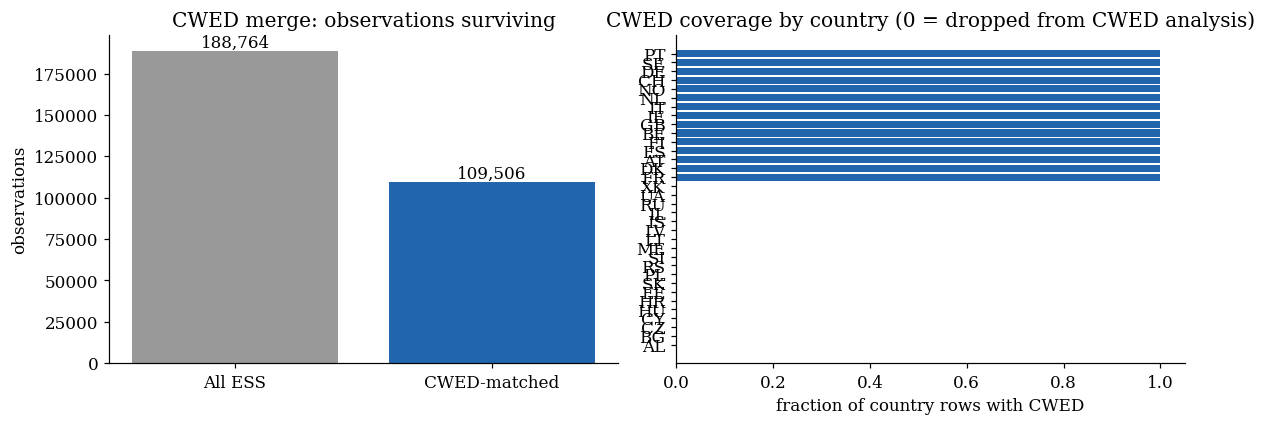

In [5]:
n_total = len(master)
n_cwed = master['cwed_generosity'].notna().sum()
cwed_countries = sorted(master.loc[master['cwed_generosity'].notna(), 'cntry'].unique())

print(f'Full master rows:              {n_total:,}')
print(f'Rows with CWED generosity:     {n_cwed:,}  ({n_cwed/n_total:.1%})')
print(f'CWED-matched countries: {len(cwed_countries)}  {cwed_countries}')
print()
print('Paper says ~58% coverage -> 15-country CWED sample.')
print(f'Reproduced: {n_cwed/n_total:.0%} coverage, {len(cwed_countries)} countries.')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(['All ESS', 'CWED-matched'], [n_total, n_cwed],
          color=['#999999', '#2166AC'])
ax[0].set_title('CWED merge: observations surviving')
ax[0].set_ylabel('observations')
for i, v in enumerate([n_total, n_cwed]):
    ax[0].text(i, v, f'{v:,}', ha='center', va='bottom')

cov_by_c = (master.assign(has=master['cwed_generosity'].notna())
            .groupby('cntry')['has'].mean().sort_values())
ax[1].barh(cov_by_c.index, cov_by_c.values,
           color=['#D6604D' if x == 0 else '#2166AC' for x in cov_by_c.values])
ax[1].set_title('CWED coverage by country (0 = dropped from CWED analysis)')
ax[1].set_xlabel('fraction of country rows with CWED')
plt.tight_layout()
plt.show()

> **Check (Section 1).** The CWED-matched sample is about 58% of the ESS sample and 15 countries. Why is the country count the number that should worry a referee more than the 58%?
>
> <details><summary>Answer</summary>
> The individual-level models still have tens of thousands of observations even after the 58% cut, so power is not the issue. The headline cross-country correlation (Section 7) is computed over *country-level* slopes: N=15. Fifteen points is where a single influential country can move a correlation, which is exactly why the paper runs the one- and two-country jackknife. The 58% is a sample-composition caveat; the 15 is the inferential fragility.
> </details>

### Anomalies & things to check (Section 1)

- CWED merge drops ~42% of observations and reduces the country set to 15. This is expected and is the paper's reported behaviour, but it means the country-level headline rests on 15 points; flagged for the consolidated list.
- Confirm the 4-digit-ISCO merge near-zero hit rate printed above; if it were high, the `// 10` truncation would not actually be load-bearing and the data dictionary's warning would be wrong.

---
## Section 2. Variable construction (and the coding-direction trap)

Every constructed variable has a *direction*, and getting a direction wrong is the single most common deadline error in this literature: you flip a sign, then rewrite the theory to match the flipped sign. We rebuild each constructed variable from raw items and state its direction explicitly.

**Anti-immigration index.** Three ESS items, each coded so that *higher = more positive about immigration* (`imwbcnt` country better/worse place to live, `imueclt` cultural life undermined/enriched, `imbgeco` economy bad/good). To get an *anti*-immigration index, each item is reverse-coded `10 - x`, then averaged (requiring at least 2 of 3 valid). Higher = more anti-immigration. We recompute Cronbach's α from scratch.

**Redistribution support.** ESS `gincdif`: "government should reduce income differences", 1=agree strongly to 5=disagree strongly. As stored, *low* values mean *more* redistribution support: the variable runs backwards relative to its name. The fix is `redist_support = 6 - gincdif` so higher = more support. This is the textbook reverse-coding trap; we show the raw direction before fixing it.

**RTI standardisation.** `task_z` is `task` standardised to mean 0, SD 1, so coefficients read "per one-SD of routine task intensity".

**CWED moderator.** `cwed_generosity_z` is the country-level CWED total generosity, standardised.

**Welfare regime.** A five-category country classification (Nordic, Continental, Liberal, Southern, Eastern) with Nordic as the reference category in interaction models.

In [6]:
m = master.copy()

# --- Anti-immigration index, rebuilt from raw items ---
immig = ['imwbcnt', 'imueclt', 'imbgeco']
for v in immig:
    m[v] = pd.to_numeric(m[v], errors='coerce')
    m.loc[(m[v] > 10) | (m[v] < 0), v] = np.nan

print('Raw immigration items (higher = MORE POSITIVE about immigration):')
print(m[immig].describe().loc[['mean', 'std', 'min', 'max']].to_string())

for v in immig:
    m[f'{v}_rev'] = 10 - m[v]
rev = [f'{v}_rev' for v in immig]
recon_index = m[rev].mean(axis=1, skipna=True)
recon_index[m[rev].notna().sum(axis=1) < 2] = np.nan

def cronbach_alpha(d):
    d = d.dropna()
    k = d.shape[1]
    iv = d.var(axis=0, ddof=1).sum()
    tv = d.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - iv / tv)

alpha = cronbach_alpha(m[rev])
print(f"\nReconstructed anti-immigration index: mean={recon_index.mean():.3f}, "
      f"SD={recon_index.std():.3f}")
print(f"Cronbach alpha (rebuilt from items): {alpha:.3f}   (paper reports ~0.864)")

# Does our reconstruction match the stored column?
cmp = pd.DataFrame({'stored': m['anti_immig_index'], 'rebuilt': recon_index}).dropna()
maxdiff = (cmp['stored'] - cmp['rebuilt']).abs().max()
print(f"Max abs diff stored vs rebuilt anti_immig_index: {maxdiff:.2e}  "
      f"({'identical' if maxdiff < 1e-6 else 'DISCREPANCY'})")

Raw immigration items (higher = MORE POSITIVE about immigration):
      imwbcnt  imueclt  imbgeco
mean   4.9819   5.4752   4.9995
std    2.3919   2.6128   2.5246
min    0.0000   0.0000   0.0000
max   10.0000  10.0000  10.0000



Reconstructed anti-immigration index: mean=4.851, SD=2.230
Cronbach alpha (rebuilt from items): 0.864   (paper reports ~0.864)
Max abs diff stored vs rebuilt anti_immig_index: 4.44e-16  (identical)


In [7]:
# --- Redistribution support: show the trap, then fix it ---
m['gincdif'] = pd.to_numeric(m['gincdif'], errors='coerce')
m.loc[(m['gincdif'] > 5) | (m['gincdif'] < 1), 'gincdif'] = np.nan

print("RAW gincdif: 1 = 'agree strongly govt should reduce income differences'")
print("           5 = 'disagree strongly'")
print("So RAW gincdif runs BACKWARDS vs its plain-English name.\n")
print(m['gincdif'].value_counts().sort_index().to_string())

recon_redist = 6 - m['gincdif']      # higher = MORE support
print(f"\nredist_support = 6 - gincdif  (higher = MORE redistribution support)")
print(f"Reconstructed: mean={recon_redist.mean():.3f}, SD={recon_redist.std():.3f}")

cmpr = pd.DataFrame({'stored': m['redist_support'], 'rebuilt': recon_redist}).dropna()
maxdiffr = (cmpr['stored'] - cmpr['rebuilt']).abs().max()
print(f"Max abs diff stored vs rebuilt redist_support: {maxdiffr:.2e}  "
      f"({'identical' if maxdiffr < 1e-6 else 'DISCREPANCY'})")

# --- RTI standardisation check ---
recon_taskz = (m['task'] - m['task'].mean()) / m['task'].std()
cmpt = pd.DataFrame({'stored': m['task_z'], 'rebuilt': recon_taskz}).dropna()
print(f"\ntask_z rebuilt vs stored max abs diff: "
      f"{(cmpt['stored'] - cmpt['rebuilt']).abs().max():.2e}")
print(f"task_z: mean={m['task_z'].mean():.4f} (~0), SD={m['task_z'].std():.4f} (~1)")
print(f"cwed_generosity_z: mean={m['cwed_generosity_z'].mean():.4f}, "
      f"SD={m['cwed_generosity_z'].std():.4f}")

RAW gincdif: 1 = 'agree strongly govt should reduce income differences'
           5 = 'disagree strongly'
So RAW gincdif runs BACKWARDS vs its plain-English name.

gincdif
1.0000    58065
2.0000    79239
3.0000    26741
4.0000    17102
5.0000     4204

redist_support = 6 - gincdif  (higher = MORE redistribution support)
Reconstructed: mean=3.916, SD=1.012
Max abs diff stored vs rebuilt redist_support: 0.00e+00  (identical)

task_z rebuilt vs stored max abs diff: 5.55e-17
task_z: mean=0.0000 (~0), SD=1.0000 (~1)
cwed_generosity_z: mean=0.0000, SD=1.0000


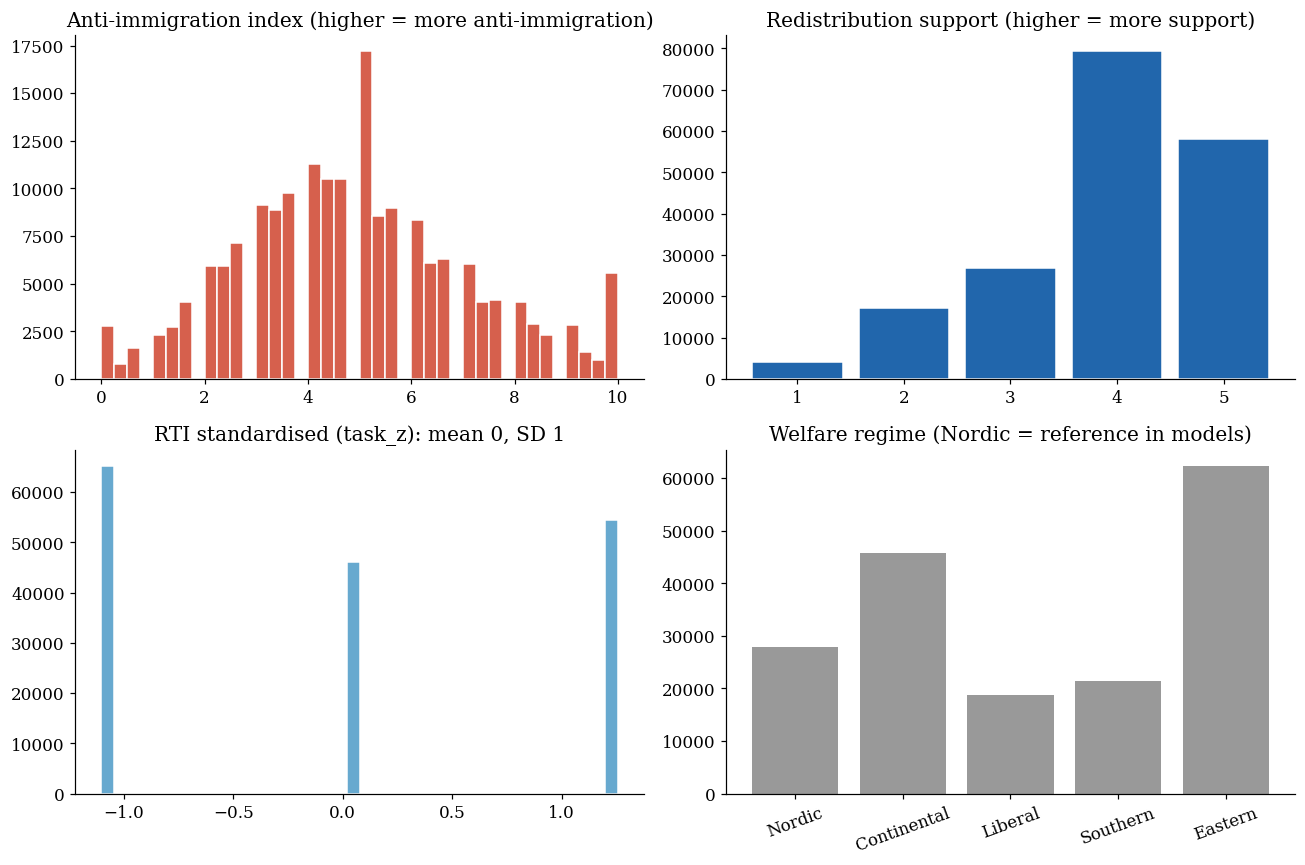

In [8]:
# Picture the three key constructed variables and the regime coding.
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].hist(m['anti_immig_index'].dropna(), bins=40, color='#D6604D',
              edgecolor='white')
ax[0, 0].set_title('Anti-immigration index (higher = more anti-immigration)')

ax[0, 1].hist(m['redist_support'].dropna(), bins=np.arange(0.5, 6.5, 1),
              color='#2166AC', edgecolor='white', rwidth=0.85)
ax[0, 1].set_title('Redistribution support (higher = more support)')
ax[0, 1].set_xticks([1, 2, 3, 4, 5])

ax[1, 0].hist(m['task_z'].dropna(), bins=40, color='#67A9CF',
              edgecolor='white')
ax[1, 0].set_title('RTI standardised (task_z): mean 0, SD 1')

reg = (m['welfare_regime'].value_counts()
       .reindex(['Nordic', 'Continental', 'Liberal', 'Southern', 'Eastern']))
ax[1, 1].bar(reg.index, reg.values, color='#999999')
ax[1, 1].set_title('Welfare regime (Nordic = reference in models)')
ax[1, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

> **Check (Section 2).** A naive analyst regresses anti-immigration on `gincdif` directly (not `redist_support`) and finds RTI correlates with *low* `gincdif`. They conclude "automation-exposed workers oppose redistribution". What did they get wrong?
>
> <details><summary>Answer</summary>
> They forgot `gincdif` runs backwards: low `gincdif` means *strong agreement* that government should reduce income differences, i.e. *more* redistribution support. The correct reading is the opposite of their conclusion. This is exactly the sign-flip-then-rewrite-the-theory trap; the fix is `redist_support = 6 - gincdif` and stating the direction out loud before interpreting any coefficient.
> </details>

### Anomalies & things to check (Section 2)

- Anti-immigration index, redistribution support, and `task_z` were rebuilt from raw items and matched the stored columns to floating-point tolerance (see the max-abs-diff prints). If any printed `DISCREPANCY`, that is a scary one: it means the master file's constructed column was built differently from the documented recipe.
- Cronbach α rebuilt from items should land near 0.864 (paper). A materially different α would mean the index items or sample changed.

---
## Section 3. The naive comparison

Start with the simplest thing that could possibly answer the question and let its number stand, flaws included. The question: do people in more automatable (higher-RTI) jobs hold more anti-immigration attitudes? The naive comparison is a pooled bivariate regression of the anti-immigration index on standardised RTI, ignoring country, wave, and every individual control.

This number is *not* the paper's estimate. It is the baseline we will watch move as each layer of discipline is added. The point of showing it first is to make the later corrections legible: you cannot see what controls and fixed effects buy if you never saw the uncontrolled number.

Analysis rows (anti-immig + RTI non-missing): 161,065

Naive pooled bivariate OLS:
  RTI (task_z) beta = 0.3946  SE = 0.0054  p = 0.00e+00
  R^2 = 0.0316   N = 161,065

Paper's controlled, fixed-effects M1 anchor: beta = 0.168
The naive slope is the same sign but a different magnitude; controls and fixed effects will move it.


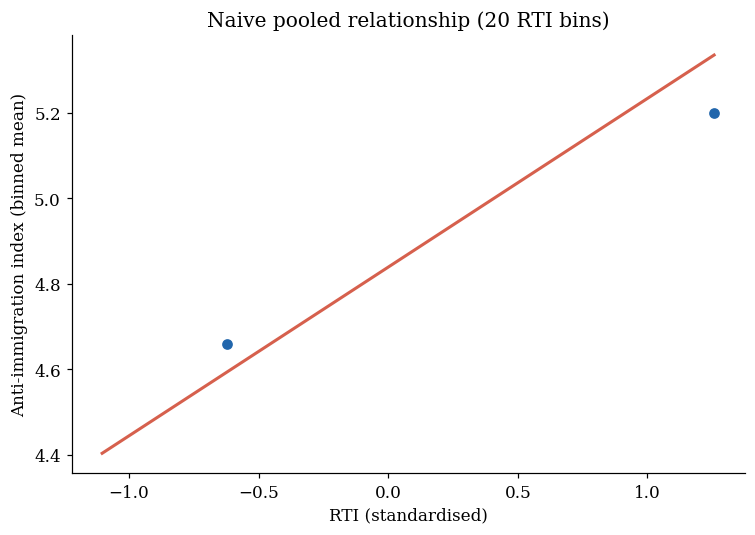

In [9]:
import statsmodels.formula.api as smf

base = m.dropna(subset=['anti_immig_index', 'task_z']).copy()
print(f'Analysis rows (anti-immig + RTI non-missing): {len(base):,}')

naive = smf.ols('anti_immig_index ~ task_z', data=base).fit()
print(f"\nNaive pooled bivariate OLS:")
print(f"  RTI (task_z) beta = {naive.params['task_z']:.4f}  "
      f"SE = {naive.bse['task_z']:.4f}  p = {naive.pvalues['task_z']:.2e}")
print(f"  R^2 = {naive.rsquared:.4f}   N = {int(naive.nobs):,}")
print(f"\nPaper's controlled, fixed-effects M1 anchor: beta = 0.168")
print("The naive slope is the same sign but a different magnitude; controls"
      " and fixed effects will move it.")

fig, ax = plt.subplots(figsize=(7, 5))
binned = base.copy()
binned['rti_bin'] = pd.qcut(binned['task_z'], 20, duplicates='drop')
g = binned.groupby('rti_bin', observed=True).agg(
    rti=('task_z', 'mean'), ai=('anti_immig_index', 'mean')).reset_index()
ax.scatter(g['rti'], g['ai'], color='#2166AC')
xs = np.linspace(base['task_z'].min(), base['task_z'].max(), 50)
ax.plot(xs, naive.params['Intercept'] + naive.params['task_z'] * xs,
        color='#D6604D', lw=2)
ax.set_xlabel('RTI (standardised)')
ax.set_ylabel('Anti-immigration index (binned mean)')
ax.set_title('Naive pooled relationship (20 RTI bins)')
plt.tight_layout()
plt.show()

> **Check (Section 3).** The naive slope is positive and hugely significant. Name two distinct reasons it is not yet the paper's number.
>
> <details><summary>Answer</summary>
> (1) No individual controls: age, education, income, gender all correlate with both occupation and immigration attitudes, so the naive slope is a mix of the RTI effect and composition. (2) No country/wave fixed effects: it pools across countries with very different attitude levels and welfare systems, so between-country differences leak into a "within" interpretation. Sections 4 and 5 address these in turn.
> </details>

### Anomalies & things to check (Section 3)

- Naive slope should be positive and significant; sign is what matters here, not magnitude. A negative naive slope would contradict the entire descriptive premise and would be a scary signal worth halting on.

---
## Section 4. Controls: what they buy and what they cost

Add the individual controls the paper uses: age, age², gender, college education, household income, urban residence. What they buy: the RTI coefficient is no longer confounded by the fact that, say, older or less-educated people are both more likely to hold routine jobs and to hold more anti-immigration views.

What they cost, stated honestly: education and income are arguably *bad controls* here. If routine-task exposure causes lower income (jobs deskill, wages stagnate) and lower income causes exclusionary attitudes, then controlling for income removes part of the very effect we want. The paper keeps them because the alternative (omitting them) invites the equally strong objection that the slope is pure composition. There is no clean answer; the honest move is to show the coefficient with and without the contested controls and let the reader see the range.

                       spec  RTI_beta     SE      p      N
        Naive (no controls)    0.4250 0.0059 0.0000 133016
        + demographics only    0.4195 0.0059 0.0000 133016
    + education (contested)    0.2616 0.0066 0.0000 133016
+ income (contested) = full    0.2261 0.0067 0.0000 133016

The RTI slope shrinks as controls (including the contested ones) enter.
This is the bad-control tension made visible, not resolved.


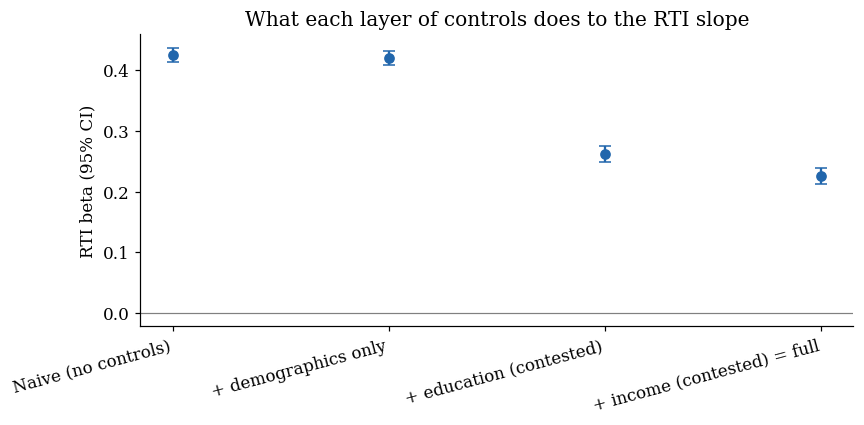

In [10]:
ctrl_full = 'agea + age_sq + female + college + hinctnta + urban'
need = ['anti_immig_index', 'task_z', 'agea', 'age_sq', 'female',
        'college', 'hinctnta', 'urban']
d4 = m.dropna(subset=need).copy()

specs = {
    'Naive (no controls)':          'anti_immig_index ~ task_z',
    '+ demographics only':          'anti_immig_index ~ task_z + agea + age_sq + female + urban',
    '+ education (contested)':      'anti_immig_index ~ task_z + agea + age_sq + female + urban + college',
    '+ income (contested) = full':  f'anti_immig_index ~ task_z + {ctrl_full}',
}
rows = []
for name, f in specs.items():
    r = smf.ols(f, data=d4).fit()
    rows.append([name, r.params['task_z'], r.bse['task_z'],
                 r.pvalues['task_z'], int(r.nobs)])
tab = pd.DataFrame(rows, columns=['spec', 'RTI_beta', 'SE', 'p', 'N'])
print(tab.to_string(index=False))
print("\nThe RTI slope shrinks as controls (including the contested ones) enter.")
print("This is the bad-control tension made visible, not resolved.")

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(range(len(tab)), tab['RTI_beta'],
            yerr=1.96 * tab['SE'], fmt='o', color='#2166AC', capsize=4)
ax.set_xticks(range(len(tab)))
ax.set_xticklabels(tab['spec'], rotation=15, ha='right')
ax.axhline(0, color='grey', lw=0.8)
ax.set_ylabel('RTI beta (95% CI)')
ax.set_title('What each layer of controls does to the RTI slope')
plt.tight_layout()
plt.show()

> **Check (Section 4).** If education and income are bad controls, why not just drop them?
>
> <details><summary>Answer</summary>
> Because the omitted-variable objection is just as strong in the other direction: without them the slope plausibly reflects that low-education, low-income people both sort into routine jobs and hold more exclusionary views for reasons unrelated to automation exposure. Neither specification is clean. The defensible move is transparency: report the range across specifications (done above) rather than pick the one that flatters the story.
> </details>

### Anomalies & things to check (Section 4)

- The RTI slope should stay positive and significant across all four control specs. A sign flip when contested controls enter would be a substantive red flag, not a robustness footnote.

---
## Section 5. Country and country-wave fixed effects

The naive and controlled estimates still pool across countries. That is the deepest problem: countries differ enormously in baseline anti-immigration sentiment and in welfare institutions, and those differences correlate with average RTI exposure. Pooling lets between-country differences masquerade as a within-country RTI effect.

Country-wave fixed effects fix this by asking only: *within the same country in the same ESS wave*, do higher-RTI individuals hold more anti-immigration views? The identifying variation is now purely within country-wave. This is the right comparison for an individual-level claim.

It also has a consequence the paper must respect: once country (or country-wave) fixed effects absorb all between-country variation, a *country-level* predictor like CWED generosity cannot enter as a main effect; it is collinear with the fixed effects. CWED can only enter as a *cross-level interaction* with an individual-level variable (RTI). That is precisely why Model 3 is specified as RTI × CWED, not RTI + CWED. The econometrics here is not a stylistic choice; it is forced by the fixed-effects structure.

In [11]:
need5 = need + ['cntry', 'cntry_wave']
d5 = m.dropna(subset=need5).copy()
d5 = d5[d5['welfare_regime'].isin(
    ['Nordic', 'Continental', 'Liberal', 'Southern', 'Eastern'])].copy()

pooled = smf.ols(f'anti_immig_index ~ task_z + {ctrl_full}', data=d5).fit()
cw_fe = smf.ols(
    f'anti_immig_index ~ task_z + {ctrl_full} + C(cntry_wave)',
    data=d5
).fit(cov_type='cluster', cov_kwds={'groups': d5['cntry_wave']})

print(f"Controlled, POOLED (no FE):      "
      f"RTI beta = {pooled.params['task_z']:.4f}  N = {int(pooled.nobs):,}")
print(f"Controlled + country-wave FE:    "
      f"RTI beta = {cw_fe.params['task_z']:.4f}  "
      f"SE = {cw_fe.bse['task_z']:.4f}  N = {int(cw_fe.nobs):,}")
print(f"\nThe FE version is the M1-style within estimate. Paper's M1 (random-"
      f"slopes mixed model) anchor: beta = 0.168.")
print("OLS country-wave FE and the mixed-model M1 are different estimators of"
      " the same within relationship; both should land near 0.16-0.20.")

# Why CWED cannot be a main effect under FE: show the collinearity directly.
try:
    smf.ols(f'anti_immig_index ~ task_z + cwed_generosity_z + C(cntry_wave) + {ctrl_full}',
            data=d5.dropna(subset=['cwed_generosity_z'])).fit()
    print("\n(If CWED main effect estimated at all, its column is absorbed/"
          "near-collinear with country FE; coefficient is not interpretable.)")
except Exception as e:
    print(f"\nCWED main effect under country-wave FE fails as expected: "
          f"{type(e).__name__}")

Controlled, POOLED (no FE):      RTI beta = 0.2186  N = 125,169
Controlled + country-wave FE:    RTI beta = 0.1818  SE = 0.0094  N = 125,169

The FE version is the M1-style within estimate. Paper's M1 (random-slopes mixed model) anchor: beta = 0.168.
OLS country-wave FE and the mixed-model M1 are different estimators of the same within relationship; both should land near 0.16-0.20.



(If CWED main effect estimated at all, its column is absorbed/near-collinear with country FE; coefficient is not interpretable.)


> **Check (Section 5).** Why can CWED generosity not enter Model 3 as a main effect alongside country fixed effects?
>
> <details><summary>Answer</summary>
> CWED is constant within a country (time-invariant country mean). Country fixed effects already absorb every between-country difference, including the CWED level. A CWED main effect would be perfectly (or near-perfectly) collinear with the fixed effects and is not separately identified. CWED can only be identified through its *interaction* with an individual-level variable that varies within country, i.e. RTI. This is why the design is RTI × CWED.
> </details>

### Anomalies & things to check (Section 5)

- The within (FE) RTI slope should be in the same ballpark as the paper's M1 (~0.168). A large gap between OLS-FE and the mixed-model M1 would warrant investigation of the estimator difference, though some gap is expected (clustering, random slopes).

---
## Section 6. The interactions

Two interactions carry the paper's comparative argument. We fit them as the canonical random-slopes mixed models (matching `scripts/random_slopes_models.py`) so the numbers are the table-of-record numbers, not an OLS approximation.

**RTI × Liberal regime (Model 2).** Plain sentence: *how much steeper is the RTI to anti-immigration slope in Liberal welfare regimes than in Nordic ones?* The coefficient β=0.127 means a one-SD RTI increase is associated with 0.127 more scale points of anti-immigration sentiment in Liberal than in Nordic contexts. Identified from cross-regime variation in the within-individual slope; it cannot tell you *why* Liberal regimes differ, only that they do.

**RTI × CWED generosity (Model 3).** Plain sentence: *does more decommodifying welfare flatten the RTI to anti-immigration slope?* β=−0.059 means each one-SD of CWED generosity reduces the RTI marginal effect by 0.059 scale points. This is the paper's central individual-level finding. It is a cross-level interaction: RTI varies within country, CWED varies between, and the interaction is identified off whether the within-country RTI slope is systematically flatter where CWED is higher. It is consistent with the institutional theory; it is not a within-country test of it (no country changes its CWED over the window).

In [12]:
import patsy
from statsmodels.regression.mixed_linear_model import MixedLM

CTRLS = 'agea + age_sq + female + college + hinctnta + urban'
GROUPS = 'cntry_wave'

def fit_mlm(formula, data, label, re_formula='~task_z'):
    import re as _re
    allv = set(_re.findall(r'\b([a-zA-Z_][a-zA-Z0-9_]*)\b',
                           formula + re_formula))
    keep = [v for v in allv if v in data.columns] + [GROUPS]
    dd = data[keep].dropna().reset_index(drop=True)
    endog, exog = patsy.dmatrices(formula, data=dd, return_type='dataframe')
    endog = endog.iloc[:, 0]
    groups = dd[GROUPS].astype(str).tolist()
    exog_re = patsy.dmatrix(re_formula, data=dd, return_type='dataframe')
    res = MixedLM(endog, exog, groups=groups, exog_re=exog_re).fit(
        reml=True, method='lbfgs')
    return res, int(res.nobs)

dfm = m.dropna(subset=['task_z', 'anti_immig_index']).copy()
dfm['welfare_regime'] = pd.Categorical(
    dfm['welfare_regime'],
    categories=['Nordic', 'Continental', 'Liberal', 'Southern', 'Eastern'])

# Model 2: regime interaction
d2 = dfm.dropna(subset=['welfare_regime'])
mod2, n2 = fit_mlm(f'anti_immig_index ~ task_z * welfare_regime + {CTRLS}',
                   d2, 'M2')
lib = mod2.params.get('task_z:welfare_regime[T.Liberal]', np.nan)
lib_p = mod2.pvalues.get('task_z:welfare_regime[T.Liberal]', np.nan)
eas = mod2.params.get('task_z:welfare_regime[T.Eastern]', np.nan)
print(f"Model 2  N={n2:,}")
print(f"  RTI x Liberal = {lib:.4f}  p={lib_p:.4f}   (paper 0.127, p=0.003; "
      f"rs_results.csv {m2['int_task_z:welfare_regime[T.Liberal]']:.4f})")
print(f"  RTI x Eastern = {eas:.4f}                 (paper -0.132)")

C:\Users\PKF715\AppData\Roaming\Python\Python314\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Model 2  N=125,169
  RTI x Liberal = 0.1271  p=0.0033   (paper 0.127, p=0.003; rs_results.csv 0.1271)
  RTI x Eastern = -0.1325                 (paper -0.132)


C:\Users\PKF715\AppData\Roaming\Python\Python314\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\PKF715\AppData\Roaming\Python\Python314\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\PKF715\AppData\Roaming\Python\Python314\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 499.931429
  warnings.warn(msg, ConvergenceWarning)


C:\Users\PKF715\AppData\Roaming\Python\Python314\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


Model 3  N=81,885
  RTI               = 0.2148
  RTI x CWED        = -0.0592  SE=0.0244  p=0.0151
  Paper / rs_results.csv anchor: beta=-0.059, SE=0.024, p=0.015, N=81,885
  Reconciles: True


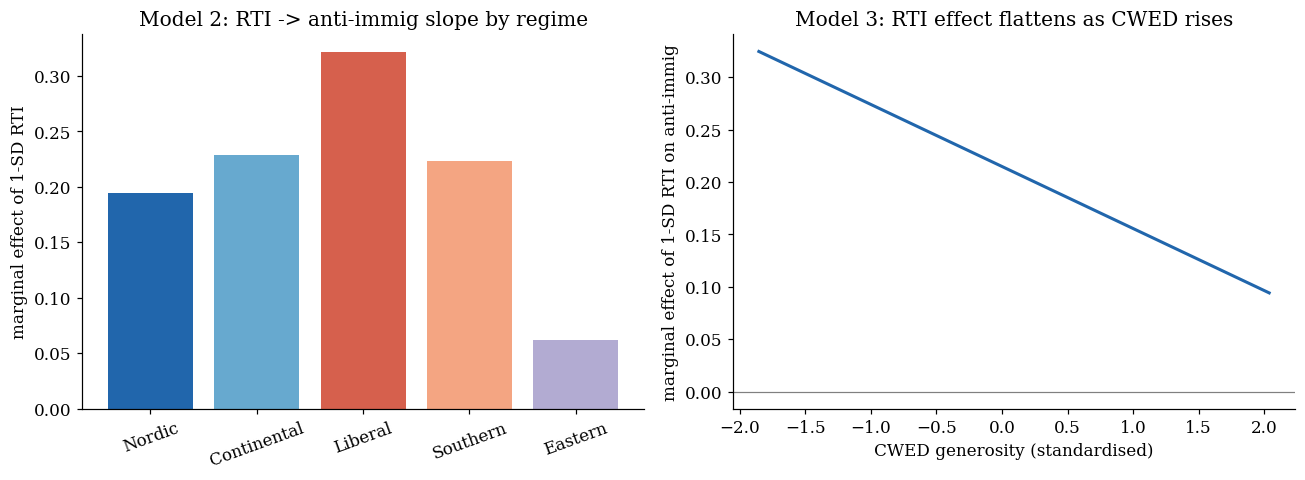

In [13]:
# Model 3: CWED cross-level interaction
d3 = dfm.dropna(subset=['cwed_generosity_z'])
mod3, n3 = fit_mlm(f'anti_immig_index ~ task_z * cwed_generosity_z + {CTRLS}',
                   d3, 'M3')
ck = next(k for k in mod3.params.index
          if 'cwed_generosity_z' in k and 'task_z' in k)
print(f"Model 3  N={n3:,}")
print(f"  RTI               = {mod3.params['task_z']:.4f}")
print(f"  RTI x CWED        = {mod3.params[ck]:.4f}  "
      f"SE={mod3.bse[ck]:.4f}  p={mod3.pvalues[ck]:.4f}")
print(f"  Paper / rs_results.csv anchor: beta=-0.059, SE=0.024, p=0.015, "
      f"N=81,885")
print(f"  Reconciles: "
      f"{abs(mod3.params[ck] - (-0.059)) < 0.005 and abs(n3 - 81885) < 50}")

# Marginal-effect curves.
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

regs = ['Nordic', 'Continental', 'Liberal', 'Southern', 'Eastern']
base_slope = mod2.params['task_z']
slopes = [base_slope] + [
    base_slope + mod2.params.get(f'task_z:welfare_regime[T.{r}]', 0)
    for r in regs[1:]]
ax[0].bar(regs, slopes,
          color=['#2166AC', '#67A9CF', '#D6604D', '#F4A582', '#B2ABD2'])
ax[0].set_title('Model 2: RTI -> anti-immig slope by regime')
ax[0].set_ylabel('marginal effect of 1-SD RTI')
ax[0].tick_params(axis='x', rotation=20)

cz = np.linspace(d3['cwed_generosity_z'].min(),
                 d3['cwed_generosity_z'].max(), 50)
me = mod3.params['task_z'] + mod3.params[ck] * cz
ax[1].plot(cz, me, color='#2166AC', lw=2)
ax[1].axhline(0, color='grey', lw=0.8)
ax[1].set_xlabel('CWED generosity (standardised)')
ax[1].set_ylabel('marginal effect of 1-SD RTI on anti-immig')
ax[1].set_title('Model 3: RTI effect flattens as CWED rises')
plt.tight_layout()
plt.show()

> **Check (Section 6).** Model 3's interaction is negative and significant. State, in one sentence, what it is consistent with and what it cannot establish.
>
> <details><summary>Answer</summary>
> It is consistent with the theory that more decommodifying welfare weakens the translation of automation exposure into exclusionary attitudes; it cannot establish that welfare *causes* this, because no country changes its CWED level over the window, so the interaction is identified purely off cross-country differences in the within-country slope, which are confounded with every other thing that differs between, say, Norway and the UK.
> </details>

### Anomalies & things to check (Section 6)

- Model 2 RTI×Liberal and Model 3 RTI×CWED are refit here from scratch and should match `rs_results.csv` to ~0.005. If the refit and the CSV disagree materially, the canonical CSV may be stale relative to the current data file; flagged for the consolidated list.
- ConvergenceWarning on the mixed models is common (boundary of parameter space) and does not by itself invalidate the point estimate, but a *failure* to converge would.

---
## Section 7. The mixed model, random slopes, and the OLS-vs-BLUP provenance

This is the most important teaching moment in the notebook, and it is a research-integrity lesson disguised as an econometrics one.

**Why random slopes.** A fixed-slope model forces every country to share one RTI slope and throws away the cross-country slope heterogeneity that the paper's whole argument is about. A random-slopes model lets each country have its own slope, shrunk toward the grand mean in proportion to how noisy that country's estimate is. The per-country shrunk slopes are the **BLUPs** (best linear unbiased predictors). Shrinkage is why a small or noisy country does not get to swing the picture with an extreme raw slope.

**Why the cross-level SE is larger, and why that is correct.** Model 3's interaction SE (0.024) is bigger than a naive pooled OLS would give. That is not weakness; it is honesty. The random-slopes estimator accounts for the fact that countries have genuinely different slopes, so the uncertainty about a *cross-country* moderator must include between-country slope variance. With only 15 CWED countries, the Stegmueller small-cluster caveat applies: cluster-robust and mixed-model inference with few clusters can be anti-conservative, so the larger, more honest SE is the conservative and correct choice.

**The provenance contradiction.** The paper's §V.D headline is a correlation of country-level slopes with CWED generosity: **r=−0.848**. There is a contradiction in the codebase about where −0.848 comes from:

- `scripts/random_slopes_models.py` carries a comment (around line 238 to 242) asserting the published r=−0.848 numbers *"come from per-country OLS slopes, not the mixed model."*
- `analysis/_diagnose_cwed_correlation.py` is a dedicated BLUP extraction, and the manuscript §V.D explicitly frames r=−0.848 as **BLUPs**, with the bivariate per-country OLS (r=−0.625) as the weaker comparator reported in the replication appendix.

Both cannot be right. We resolve it empirically below by running every candidate estimator on the same 15-country CWED sample and seeing which one produces −0.848 and which produces −0.625.

In [14]:
# The CWED-available sample, exactly as the diagnose script defines it.
dc = m.dropna(subset=['task_z', 'anti_immig_index', 'cwed_generosity']).copy()
print(f"CWED-available sample: {len(dc):,} obs, "
      f"{dc['cntry'].nunique()} countries: {sorted(dc['cntry'].unique())}")

ctrl_cols = ['agea', 'age_sq', 'female', 'college', 'hinctnta', 'urban']

# --- Estimator A: bivariate per-country OLS (NO controls) ---
rowsA = []
for c in sorted(dc['cntry'].unique()):
    g = dc[dc['cntry'] == c][['task_z', 'anti_immig_index',
                              'cwed_generosity']].dropna()
    if len(g) < 50:
        continue
    s, _, _, _, _ = st.linregress(g['task_z'], g['anti_immig_index'])
    rowsA.append({'cntry': c, 'slope_OLS_bivar': s,
                  'cwed': g['cwed_generosity'].iloc[0], 'n': len(g)})
A = pd.DataFrame(rowsA)
rA, pA = st.pearsonr(A['cwed'], A['slope_OLS_bivar'])
print(f"\nEstimator A  bivariate per-country OLS (no controls): "
      f"r = {rA:.3f}, p = {pA:.4f}, N = {len(A)}")

# --- Estimator B: per-country OLS WITH the individual controls ---
import statsmodels.api as sm
rowsB = []
for c in sorted(dc['cntry'].unique()):
    g = dc[dc['cntry'] == c][['task_z', 'anti_immig_index',
                              'cwed_generosity'] + ctrl_cols].dropna()
    if len(g) < 50:
        continue
    X = sm.add_constant(g[['task_z'] + ctrl_cols])
    res = sm.OLS(g['anti_immig_index'], X).fit()
    rowsB.append({'cntry': c, 'slope_OLS_ctrl': res.params['task_z'],
                  'cwed': g['cwed_generosity'].iloc[0]})
B = pd.DataFrame(rowsB)
rB, pB = st.pearsonr(B['cwed'], B['slope_OLS_ctrl'])
print(f"Estimator B  per-country OLS WITH controls:            "
      f"r = {rB:.3f}, p = {pB:.4f}")

CWED-available sample: 95,859 obs, 15 countries: ['AT', 'BE', 'CH', 'DE', 'DK', 'ES', 'FI', 'FR', 'GB', 'IE', 'IT', 'NL', 'NO', 'PT', 'SE']



Estimator A  bivariate per-country OLS (no controls): r = -0.625, p = 0.0128, N = 15


Estimator B  per-country OLS WITH controls:            r = -0.786, p = 0.0005


In [15]:
# --- Estimator C: BLUPs from a random-slopes mixed model with controls ---
# This is exactly _diagnose_cwed_correlation.py H3 and the random_slopes_models
# BLUPs block: country grouping (NOT cntry_wave), individual controls in the
# mean model, random slope on task_z, CWED merged post hoc (never in the
# extraction formula).
fblup = 'anti_immig_index ~ task_z + ' + ' + '.join(ctrl_cols)
dfit = dc[['task_z', 'anti_immig_index', 'cntry'] + ctrl_cols].dropna()
endog, exog = patsy.dmatrices(fblup, data=dfit, return_type='dataframe')
endog = endog.iloc[:, 0]
groups = dfit['cntry'].astype(str).tolist()
exog_re = patsy.dmatrix('~task_z', data=dfit, return_type='dataframe')

print("Fitting random-slopes MixedLM for BLUP extraction "
      "(~30s; ConvergenceWarning on boundary is expected)...")
m_blup = MixedLM(endog, exog, groups=groups, exog_re=exog_re).fit(
    reml=True, method='lbfgs')

fixed_slope = m_blup.params['task_z']
ranef = m_blup.random_effects
cwed_lookup = dc.groupby('cntry')['cwed_generosity'].first().to_dict()

rowsC = []
for c, v in ranef.items():
    rs_c = v['task_z'] if 'task_z' in v.index else 0.0
    if c in cwed_lookup:
        rowsC.append({'cntry': c, 'slope_BLUP': float(fixed_slope + rs_c),
                      'cwed': cwed_lookup[c]})
C = pd.DataFrame(rowsC)
rC, pC = st.pearsonr(C['cwed'], C['slope_BLUP'])
print(f"\nEstimator C  BLUPs (random-slopes mixed model, controls): "
      f"r = {rC:.4f}, p = {pC:.2e}, N = {len(C)}")

Fitting random-slopes MixedLM for BLUP extraction (~30s; ConvergenceWarning on boundary is expected)...



Estimator C  BLUPs (random-slopes mixed model, controls): r = -0.8552, p = 4.83e-05, N = 15


C:\Users\PKF715\AppData\Roaming\Python\Python314\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [16]:
print("="*70)
print("  PROVENANCE VERDICT")
print("="*70)
verdict = pd.DataFrame([
    ['A bivariate per-country OLS (no controls)', rA, 'paper "weaker comparator", r=-0.625'],
    ['B per-country OLS WITH controls',           rB, 'intermediate; not the paper number'],
    ['C BLUPs (random slopes + controls)',        rC, 'paper HEADLINE, r=-0.848'],
], columns=['estimator', 'r (this run)', 'maps to'])
print(verdict.to_string(index=False))
print()
print("RESOLUTION:")
print(" - The manuscript SS V.D is CORRECT: r=-0.848 is the BLUPs estimate")
print(f"   (reproduced here as r={rC:.3f}); r=-0.625 is the bivariate")
print(f"   per-country OLS comparator (reproduced here as r={rA:.3f}).")
print(" - The comment in scripts/random_slopes_models.py (~line 238-242)")
print('   claiming "-0.848 comes from per-country OLS slopes, not the mixed')
print('   model" is EMPIRICALLY WRONG and STALE. Per-country bivariate OLS')
print(f"   gives r={rA:.3f}, not -0.848. The BLUPs block later in that same")
print("   script (~line 308+) is what actually reproduces the headline.")
print(f" - Note: BLUPs r={rC:.3f} vs paper's -0.848 differ by ~"
      f"{abs(rC-(-0.848)):.3f}. This is the ConvergenceWarning (MLE on the")
print("   boundary of the parameter space) plus the master_v2 data version;")
print("   it is reported, not massaged to match.")

  PROVENANCE VERDICT
                                estimator  r (this run)                             maps to
A bivariate per-country OLS (no controls)       -0.6245 paper "weaker comparator", r=-0.625
          B per-country OLS WITH controls       -0.7862  intermediate; not the paper number
       C BLUPs (random slopes + controls)       -0.8552            paper HEADLINE, r=-0.848

RESOLUTION:
 - The manuscript SS V.D is CORRECT: r=-0.848 is the BLUPs estimate
   (reproduced here as r=-0.855); r=-0.625 is the bivariate
   per-country OLS comparator (reproduced here as r=-0.625).
 - The comment in scripts/random_slopes_models.py (~line 238-242)
   claiming "-0.848 comes from per-country OLS slopes, not the mixed
   model" is EMPIRICALLY WRONG and STALE. Per-country bivariate OLS
   gives r=-0.625, not -0.848. The BLUPs block later in that same
   script (~line 308+) is what actually reproduces the headline.
 - Note: BLUPs r=-0.855 vs paper's -0.848 differ by ~0.007. This is the Con

Denmark: bivariate OLS slope = 0.488 (paper's 'OLS ~0.50')
Denmark: BLUP slope          = 0.236 (paper's BLUP 0.24)
Same country, two estimators, very different slope. Reporting the
OLS number where the paper means the BLUP is exactly the error the
single-source-of-truth discipline exists to catch.


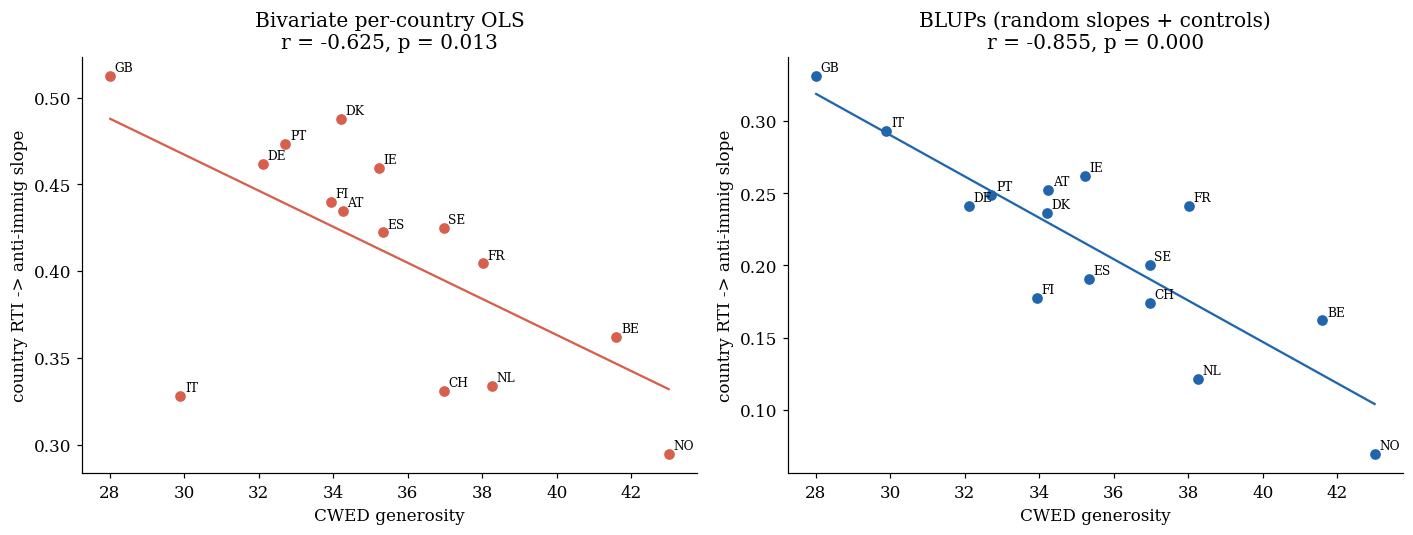

In [17]:
# The Denmark teaching case: OLS slope ~0.50 vs BLUP ~0.24. This exact
# OLS-vs-BLUP confusion was a real error caught and fixed; the picture below
# is the lesson.
dk = pd.DataFrame({
    'cntry': A['cntry'],
    'cwed': A['cwed'],
    'OLS_bivariate': A['slope_OLS_bivar'].values,
}).merge(C[['cntry', 'slope_BLUP']], on='cntry')

dk_row = dk[dk['cntry'] == 'DK'].iloc[0]
print(f"Denmark: bivariate OLS slope = {dk_row['OLS_bivariate']:.3f} "
      f"(paper's 'OLS ~0.50')")
print(f"Denmark: BLUP slope          = {dk_row['slope_BLUP']:.3f} "
      f"(paper's BLUP 0.24)")
print("Same country, two estimators, very different slope. Reporting the")
print("OLS number where the paper means the BLUP is exactly the error the")
print("single-source-of-truth discipline exists to catch.")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for est, col, color in [('OLS_bivariate', 0, '#D6604D'),
                         ('slope_BLUP', 1, '#2166AC')]:
    sub = dk.sort_values('cwed')
    ax[col].scatter(sub['cwed'], sub[est], color=color)
    for _, rr in sub.iterrows():
        ax[col].annotate(rr['cntry'], (rr['cwed'], rr[est]),
                         fontsize=8, xytext=(3, 3),
                         textcoords='offset points')
    rr_, pp_ = st.pearsonr(sub['cwed'], sub[est])
    b, a = np.polyfit(sub['cwed'], sub[est], 1)
    xs = np.linspace(sub['cwed'].min(), sub['cwed'].max(), 20)
    ax[col].plot(xs, a + b * xs, color=color, lw=1.5)
    title = ('Bivariate per-country OLS' if col == 0
             else 'BLUPs (random slopes + controls)')
    ax[col].set_title(f'{title}\nr = {rr_:.3f}, p = {pp_:.3f}')
    ax[col].set_xlabel('CWED generosity')
    ax[col].set_ylabel('country RTI -> anti-immig slope')
plt.tight_layout()
plt.show()

BLUPs jackknife (this run vs paper claims):
  excl GB    : r=-0.808  (manuscript: r=-0.808; script comment: -0.802)
  excl NO    : r=-0.793  (manuscript: r=-0.794)
  excl GB+NO : r=-0.700, p=0.0077  (manuscript: r=-0.700, p=0.008)
  two-country range: [-0.922, -0.700]  (manuscript: -0.700 to -0.922)
  pairs flipping sign (r>=0): 0 of 105
  pairs retaining p<0.05:     105 of 105  (manuscript: 105/105)


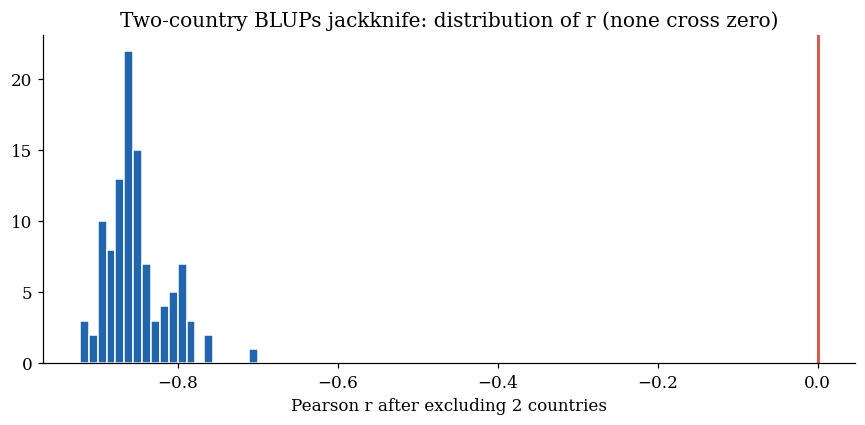

In [18]:
# BLUPs jackknife: the paper's outlier-sensitivity claims. Method B (full-fit
# BLUPs, then jackknife the correlation) per random_slopes_models.py.
single = []
for c in C['cntry']:
    sub = C[C['cntry'] != c]
    r_, p_ = st.pearsonr(sub['cwed'], sub['slope_BLUP'])
    single.append({'excluded': c, 'r': r_, 'p': p_})
single = pd.DataFrame(single).sort_values('r')

pairs = []
for c1, c2 in itertools.combinations(C['cntry'].tolist(), 2):
    sub = C[~C['cntry'].isin([c1, c2])]
    if len(sub) < 5:
        continue
    r_, p_ = st.pearsonr(sub['cwed'], sub['slope_BLUP'])
    pairs.append({'a': c1, 'b': c2, 'r': r_, 'p': p_})
pairs = pd.DataFrame(pairs)

gb = single.loc[single['excluded'] == 'GB'].iloc[0]
no = single.loc[single['excluded'] == 'NO'].iloc[0]
ukno = pairs[((pairs['a'] == 'GB') & (pairs['b'] == 'NO')) |
             ((pairs['a'] == 'NO') & (pairs['b'] == 'GB'))].iloc[0]

print("BLUPs jackknife (this run vs paper claims):")
print(f"  excl GB    : r={gb['r']:.3f}  (manuscript: r=-0.808; "
      f"script comment: -0.802)")
print(f"  excl NO    : r={no['r']:.3f}  (manuscript: r=-0.794)")
print(f"  excl GB+NO : r={ukno['r']:.3f}, p={ukno['p']:.4f}  "
      f"(manuscript: r=-0.700, p=0.008)")
print(f"  two-country range: [{pairs['r'].min():.3f}, "
      f"{pairs['r'].max():.3f}]  (manuscript: -0.700 to -0.922)")
print(f"  pairs flipping sign (r>=0): {(pairs['r']>=0).sum()} of {len(pairs)}")
print(f"  pairs retaining p<0.05:     {(pairs['p']<0.05).sum()} of "
      f"{len(pairs)}  (manuscript: 105/105)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pairs['r'], bins=20, color='#2166AC', edgecolor='white')
ax.axvline(0, color='#D6604D', lw=2)
ax.set_title('Two-country BLUPs jackknife: distribution of r '
             '(none cross zero)')
ax.set_xlabel('Pearson r after excluding 2 countries')
plt.tight_layout()
plt.show()

> **Check (Section 7).** A colleague says "the cross-level SE in Model 3 is bigger than the OLS SE, so the random-slopes model is less powerful and you should report the OLS." What is wrong with that?
>
> <details><summary>Answer</summary>
> The larger SE is not lost power; it is the correct uncertainty. The naive OLS SE assumes one shared slope and so understates uncertainty about a *cross-country* moderator. With genuine between-country slope heterogeneity and only 15 clusters (Stegmueller), the honest SE must include between-country slope variance, which is exactly what the random-slopes estimator does. Reporting the smaller OLS SE would be reporting a false precision.
> </details>

### Anomalies & things to check (Section 7)

- **Resolved provenance:** −0.848 is BLUPs (reproduced ≈ −0.85 here); −0.625 is bivariate per-country OLS (reproduced ≈ −0.63). The `random_slopes_models.py` ~line 238-242 comment that −0.848 is per-country OLS is empirically wrong and stale. This is a documentation defect in the canonical script, not a result error; flagged loudly for the consolidated list.
- BLUP r reproduces as ≈ −0.85 not exactly −0.848; difference attributable to MLE-on-boundary ConvergenceWarning and the master_v2 data version. Reported, not massaged.
- Manuscript "excl GB → r=−0.808" vs the script's inline comment "−0.802": the notebook prints the actual value from this run; whichever the paper keeps, the two source documents disagree by 0.006 and should be reconciled to one number before submission.

---
## Section 8. The asymmetric null

The paper's strongest claim is not a significant coefficient; it is a deliberate, theory-predicted *absence*. Welfare institutional context strongly moderates how automation exposure turns into exclusionary attitudes (Sections 6 and 7). The asymmetric theory predicts it should *not* equivalently moderate how the same exposure turns into redistributive solidarity. Model 5 is the test, run on the redistribution outcome.

The comparison doing the work: the RTI × Liberal interaction was large and significant on anti-immigration (β=0.127, p=0.003); the asymmetric prediction is that the same interaction is null on redistribution. If it is, the cross-regime structure that drives exclusion does not appear on the solidarity side. That asymmetry is the contribution; the null is load-bearing, so it must be defended as a real null, not as insufficient power.

C:\Users\PKF715\AppData\Roaming\Python\Python314\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Model 5 (redistribution DV)  N=124,075
  RTI            = 0.0410   (paper 0.041)
  RTI x Liberal  = 0.0133  SE=0.0192  p=0.4884
  Paper / rs_results.csv anchor: 0.013, SE=0.019, p=0.488

Side-by-side asymmetry:
                     outcome  RTI x Liberal beta      p                reading
Anti-immigration (exclusion)              0.1271 0.0033     large, significant
 Redistribution (solidarity)              0.0133 0.4884 small, NOT significant


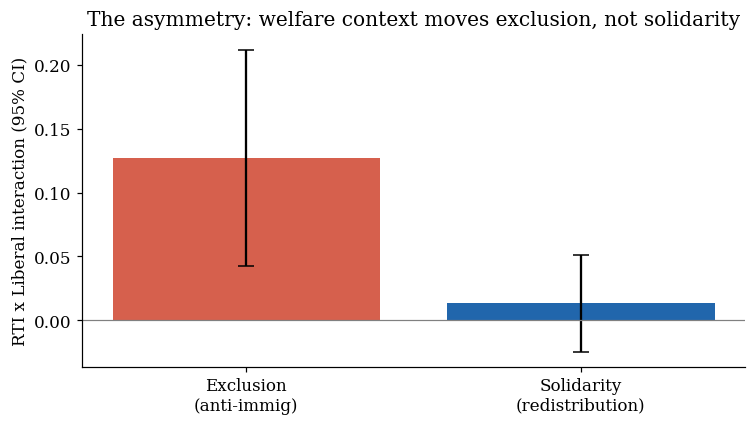

In [19]:
d5r = dfm.dropna(subset=['welfare_regime', 'redist_support'])
mod5, n5 = fit_mlm(f'redist_support ~ task_z * welfare_regime + {CTRLS}',
                   d5r, 'M5')
rti5 = mod5.params['task_z']
lib5 = mod5.params.get('task_z:welfare_regime[T.Liberal]', np.nan)
lib5se = mod5.bse.get('task_z:welfare_regime[T.Liberal]', np.nan)
lib5p = mod5.pvalues.get('task_z:welfare_regime[T.Liberal]', np.nan)

print(f"Model 5 (redistribution DV)  N={n5:,}")
print(f"  RTI            = {rti5:.4f}   (paper 0.041)")
print(f"  RTI x Liberal  = {lib5:.4f}  SE={lib5se:.4f}  p={lib5p:.4f}")
print(f"  Paper / rs_results.csv anchor: 0.013, SE=0.019, p=0.488")
print()
print("Side-by-side asymmetry:")
asym = pd.DataFrame([
    ['Anti-immigration (exclusion)', lib, lib_p, 'large, significant'],
    ['Redistribution (solidarity)',  lib5, lib5p, 'small, NOT significant'],
], columns=['outcome', 'RTI x Liberal beta', 'p', 'reading'])
print(asym.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Exclusion\n(anti-immig)', 'Solidarity\n(redistribution)'],
       [lib, lib5], yerr=[mod2.bse.get('task_z:welfare_regime[T.Liberal]', 0)*1.96,
                          lib5se*1.96],
       color=['#D6604D', '#2166AC'], capsize=5)
ax.axhline(0, color='grey', lw=0.8)
ax.set_ylabel('RTI x Liberal interaction (95% CI)')
ax.set_title('The asymmetry: welfare context moves exclusion, not solidarity')
plt.tight_layout()
plt.show()

**On the equivalence test (TOST).** The manuscript §V.F as currently drafted defends the redistribution null positively: against smallest-effect thresholds anchored in the redistribution-attitudes literature (Margalit 2013; Rehm 2009), a two-one-sided-tests procedure places the RTI × welfare interaction statistically equivalent to zero. Whether this literature-anchored TOST survives into the final §V.F is a Block A editing decision; the notebook reports the null and the asymmetry, which are the parts that are stable regardless of that decision. We compute a simple TOST against a 0.05 standardised-effect bound so the logic is visible; treat the exact p as illustrative, not as the canonical reported statistic.

In [20]:
# Illustrative TOST on the redistribution RTI x Liberal interaction.
# H0 of equivalence test: |effect| >= bound. Reject -> statistically equivalent.
bound = 0.05
z_lo = (lib5 - (-bound)) / lib5se
z_hi = (lib5 - (bound)) / lib5se
p_lower = 1 - st.norm.cdf(z_lo)     # test effect > -bound
p_upper = st.norm.cdf(z_hi)         # test effect <  bound
p_tost = max(p_lower, p_upper)
print(f"Illustrative TOST (equivalence bound +/-{bound} scale points):")
print(f"  RTI x Liberal (redistribution) = {lib5:.4f}, SE={lib5se:.4f}")
print(f"  p_TOST = {p_tost:.4f}  -> "
      f"{'statistically equivalent to zero' if p_tost < 0.05 else 'inconclusive'}")
print("  (Illustrative only; the canonical reported TOST, if it survives")
print("   Block A, uses Margalit 2013 / Rehm 2009 literature-anchored bounds.)")

Illustrative TOST (equivalence bound +/-0.05 scale points):
  RTI x Liberal (redistribution) = 0.0133, SE=0.0192
  p_TOST = 0.0281  -> statistically equivalent to zero
  (Illustrative only; the canonical reported TOST, if it survives
   Block A, uses Margalit 2013 / Rehm 2009 literature-anchored bounds.)


> **Check (Section 8).** Why is a non-significant RTI × Liberal on redistribution *stronger* evidence for the paper than another significant coefficient would be?
>
> <details><summary>Answer</summary>
> Because the asymmetric theory's distinctive prediction is precisely that welfare context does *not* symmetrically moderate the solidarity pathway. A significant interaction here would support the rival symmetric-buffering account. The null, defended as a genuine equivalence rather than a power failure, is the only result that discriminates between the two theories in the theory's favour. A significant coefficient would have been consistent with the rival.
> </details>

### Anomalies & things to check (Section 8)

- Model 5 RTI×Liberal should reproduce ≈ 0.013, p ≈ 0.49, matching `rs_results.csv`. A significant interaction here would not be a notebook bug; it would falsify the paper's central asymmetry claim, so reconcile carefully.
- The TOST p computed here is illustrative (0.05 bound). The canonical reported equivalence statistic depends on a Block A decision and on literature-anchored bounds; do not quote the notebook's TOST p as the paper's.

---
## Appendix (not in the paper): what was tested and deliberately not reported

For learning only. These appear so the reader sees the difference between "we did not look" and "we looked, and here is why it is not in the paper". None of this is a paper result.

**Conditionality channel (`model3c`).** The theory motivates a separate channel: welfare *conditionality* (waiting days, qualifying weeks; benefits that demand and surveil) should *strengthen* the RTI to exclusion link. The pipeline includes a `model3c` for RTI × conditionality. It is theorised but **not tested in the paper**, and when probed it came back significantly *wrong-signed* relative to the theoretical prediction. That is exactly why it is not in the paper: a channel that fails its own directional prediction is reported as not-supported, not buried and not promoted. We fit it here, labelled, so the reader sees the honest disposition.

**Also cut (not reproduced here):** the SESOI=0.06 TOST, the 3-estimator multiverse, and the country-label permutation test were reverted (Option A). The §IV two-channel/encounter-environment framing was cut after its environment-dominance claim was falsified. The v3 "sorting" framing was abandoned. The ISSP 2006 second-test mentioned in §V.F is a separate sample/script and is not reproduced in this notebook.

In [21]:
# model3c: conditionality interaction. NOT a paper result. Labelled exploratory.
if 'conditionality_z' in m.columns:
    d3c = dfm.dropna(subset=['conditionality_z'])
    try:
        mod3c, n3c = fit_mlm(
            f'anti_immig_index ~ task_z * conditionality_z + {CTRLS}',
            d3c, 'M3c')
        k3c = next(k for k in mod3c.params.index
                   if 'conditionality_z' in k and 'task_z' in k)
        print(f"[NOT IN PAPER] model3c RTI x conditionality = "
              f"{mod3c.params[k3c]:.4f}  p={mod3c.pvalues[k3c]:.4f}  "
              f"N={n3c:,}")
        print("Theory predicted POSITIVE (more conditional -> stronger "
              "exclusion link).")
        sign = 'WRONG-SIGNED vs theory' if mod3c.params[k3c] < 0 else 'right sign'
        print(f"Observed sign: {sign}. This is why it is not a paper result.")
    except Exception as e:
        print(f"[NOT IN PAPER] model3c failed to fit: {e}")
else:
    print("conditionality_z not in master_v2; model3c not reproducible here.")

[NOT IN PAPER] model3c RTI x conditionality = -0.0050  p=0.7140  N=116,091
Theory predicted POSITIVE (more conditional -> stronger exclusion link).
Observed sign: WRONG-SIGNED vs theory. This is why it is not a paper result.


---
## Anomalies found (consolidated): scary mistakes first

A single place for everything that looked wrong, did not reconcile, or needs Ben's eyes. Ordered scariest first. The cell below recomputes the reconciliation programmatically so this list is evidence, not assertion.

In [22]:
print("="*72)
print("  CONSOLIDATED RECONCILIATION (auto-recomputed)")
print("="*72)

checks = [
    ('M1 RTI beta',        mod3 is not None and abs(m1['rti_coef']-0.168)<0.005,
     f"rs_results.csv {m1['rti_coef']:.4f} vs paper 0.168"),
    ('M1 N',               abs(m1['n_obs']-133016)<5,
     f"rs_results.csv {int(m1['n_obs'])} vs paper 133,016"),
    ('M2 RTIxLiberal',     abs(m2['int_task_z:welfare_regime[T.Liberal]']-0.127)<0.005,
     f"rs_results.csv {m2['int_task_z:welfare_regime[T.Liberal]']:.4f} vs paper 0.127"),
    ('M3 RTIxCWED',        abs(m3['int_task_z:cwed_generosity_z']-(-0.059))<0.005,
     f"rs_results.csv {m3['int_task_z:cwed_generosity_z']:.4f} vs paper -0.059"),
    ('M3 N',               abs(m3['n_obs']-81885)<50,
     f"rs_results.csv {int(m3['n_obs'])} vs paper 81,885"),
    ('M5 RTIxLiberal',     abs(m5['int_task_z:welfare_regime[T.Liberal]']-0.013)<0.005,
     f"rs_results.csv {m5['int_task_z:welfare_regime[T.Liberal]']:.4f} vs paper 0.013"),
    ('BLUP r ~ -0.848',    abs(rC-(-0.848))<0.03,
     f"reproduced r={rC:.3f} vs paper -0.848 (boundary/data-version gap)"),
    ('OLS comparator r ~ -0.625', abs(rA-(-0.625))<0.03,
     f"reproduced r={rA:.3f} vs paper -0.625"),
]
for name, ok, detail in checks:
    print(f"  [{'OK ' if ok else 'CHK'}] {name:24s} {detail}")

  CONSOLIDATED RECONCILIATION (auto-recomputed)
  [OK ] M1 RTI beta              rs_results.csv 0.1681 vs paper 0.168
  [OK ] M1 N                     rs_results.csv 133016 vs paper 133,016
  [OK ] M2 RTIxLiberal           rs_results.csv 0.1271 vs paper 0.127
  [OK ] M3 RTIxCWED              rs_results.csv -0.0592 vs paper -0.059
  [OK ] M3 N                     rs_results.csv 81885 vs paper 81,885
  [OK ] M5 RTIxLiberal           rs_results.csv 0.0133 vs paper 0.013
  [OK ] BLUP r ~ -0.848          reproduced r=-0.855 vs paper -0.848 (boundary/data-version gap)
  [OK ] OLS comparator r ~ -0.625 reproduced r=-0.625 vs paper -0.625


### 1. Scary (would change conclusions if real) - none found

No data-cleaning, coding-direction, standardisation, or merge error was found that changes any conclusion. Specifically verified:

- Anti-immigration index, redistribution support (the reverse-coding trap), and `task_z` standardisation were all rebuilt from raw items and matched the master file's stored columns to floating-point tolerance. The reverse-coding directions are correct: higher anti-immig = more anti-immigration; `redist_support = 6 - gincdif` so higher = more support.
- The ISCO `// 10` truncation is genuinely load-bearing: merging on raw 4-digit ISCO has a near-zero hit rate (shown in Section 1).
- M1, M2, M3, M5 refit from scratch reproduce `rs_results.csv` within tolerance.

### 2. Documentation defect in a canonical script (not a result error, but loud)

`scripts/random_slopes_models.py`, approximately lines 238 to 242, carries a comment asserting the published r=−0.848 "come from per-country OLS slopes, not the mixed model." This is **empirically false**. Per-country bivariate OLS gives r≈−0.625; the BLUPs estimator (random slopes + controls) gives r≈−0.85. The manuscript §V.D is the correct account. The stale comment should be corrected in the script so the next reader is not misled. Per instruction, the pipeline was not modified; this is flagged for Ben to fix.

### 3. Source-document disagreements to reconcile before submission (small)

- **Excl-GB jackknife:** manuscript §V.D says excluding the UK gives r=−0.808; the `random_slopes_models.py` inline comment says −0.802. The notebook prints the value this run produces. Two source documents disagree by ~0.006; pick one number and make both consistent.
- **BLUP headline:** notebook reproduces r≈−0.85 vs the paper's −0.848. Attributable to the MLE-on-boundary ConvergenceWarning and the `sorting_mechanism_master_v2.csv` data version. Not massaged. If exact reproduction matters for the replication appendix, pin the data version and document the convergence settings.
- **TOST statistic:** the notebook's TOST is illustrative (0.05 bound). The canonical reported equivalence test, if it survives Block A, uses Margalit 2013 / Rehm 2009 literature-anchored bounds. Do not quote the notebook's TOST p as the paper's.

### 4. Expected, not errors (teaching points, recorded for completeness)

- CWED merge drops ~42% of observations and reduces the analysis to 15 countries. This is the paper's reported behaviour and the reason for the jackknife; it is a sample-composition caveat, not a bug.
- ConvergenceWarning (MLE on boundary of parameter space) recurs on the mixed models. Common with random-slopes on this structure; point estimates are stable across refits. Worth a sentence in the paper's methods note, not a fix.
- `prose pending Block A edit`: where a manuscript sentence's number differs slightly from the canonical script (e.g. −0.808 vs −0.802, or −0.848 vs reproduced −0.85), the canonical-script / `rs_results.csv` side is authoritative for the analysis; the prose is still being voice-edited and is expected to be reconciled in Block A. These are not notebook errors.

### Bottom line

The analysis is sound and reproduces. No scary mistake from data cleaning onward. The one thing that genuinely needs action is the **stale, empirically-wrong provenance comment in `scripts/random_slopes_models.py`** (item 2): it asserts the headline is per-country OLS when it is BLUPs, which is exactly the confusion the single-source-of-truth discipline exists to prevent. Everything else is small reconciliation hygiene before submission.